# Introduction à Pandas

Lino Galiana  
2023-12-20

Pour essayer les exemples présents dans ce tutoriel :

Le *package* `Pandas` est l’une des briques centrales de l’écosystème de
la *data science*. Le *DataFrame*,
objet central dans des langages comme `R`
ou `Stata`, a longtemps était un grand absent dans l’écosystème `Python`.
Pourtant, grâce à `Numpy`, toutes les briques de base étaient présentes.
Wes McKinney, lorsqu’il a créé `Pandas` en s’appuyant sur `Numpy`
a ainsi introduit cet objet devenu banal qu’est le *DataFrame*.
`Pandas` est rapidement
devenu un incontournable de la *data-science*. L’ouvrage
de référence de McKinney (2012) présente de manière plus
ample ce *package*.

Ce tutoriel vise à introduire aux concepts
de base de ce package par l’exemple et à introduire à certaines
des tâches les plus fréquentes de (re)structuration
des données du *data scientist*. Il ne s’agit pas d’un ensemble
exhaustif de commandes : `Pandas` est un package tentaculaire
qui permet de réaliser la même opération de nombreuses manières.
Nous nous concentrerons ainsi sur les éléments les plus pertinents
dans le cadre d’une introduction à la *data science* et laisserons
les utilisateurs intéressés approfondir leurs connaissances
dans les ressources foisonnantes qu’il existe sur le sujet.

Dans ce tutoriel `Pandas`, nous allons utiliser :

-   Les émissions de gaz à effet de serre estimées au niveau communal par l’ADEME. Le jeu de données est
    disponible sur [data.gouv](https://www.data.gouv.fr/fr/datasets/inventaire-de-gaz-a-effet-de-serre-territorialise/#_)
    et requêtable directement dans `Python` avec
    [cet url](https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert).

Le [chapitre suivant](02b_pandas_TP) permettra de mettre en application des éléments présents dans ce chapitre avec
les données ci-dessus associées à des données de contexte au niveau communal.

Nous suivrons les conventions habituelles dans l’import des packages :

In [1]:
!pip install pynsee

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pynsee.download

Pour obtenir des résultats reproductibles, on peut fixer la racine du générateur
pseudo-aléatoire.

In [3]:
np.random.seed(123)

Au cours de cette démonstration des principales fonctionalités de `Pandas`, et
lors du chapitre suivant,
je recommande de se référer régulièrement aux ressources suivantes :

-   L’[aide officielle de `Pandas`](https://pandas.pydata.org/docs/user_guide/index.html).
    Notamment, la
    [page de comparaison des langages](https://pandas.pydata.org/pandas-docs/stable/getting_started/comparison/index.html)
    qui est très utile ;
-   [Ce tutoriel](https://observablehq.com/@observablehq/data-wrangling-translations),
    pensé certes pour les utilisateurs d’[`Observable Javascript`](https://observablehq.com),
    mais qui offre de nombreux exemples intéressants pour les afficionados de `Pandas` ;
-   La *cheatsheet suivante*, [issue de ce post](https://becominghuman.ai/cheat-sheets-for-ai-neural-networks-machine-learning-deep-learning-big-data-678c51b4b463)

![Cheasheet `Pandas`](https://cdn-images-1.medium.com/max/2000/1*YhTbz8b8Svi22wNVvqzneg.jpeg)

## Logique de `Pandas`

L’objet central dans la logique `Pandas` est le `DataFrame`.
Il s’agit d’une structure particulière de données
à deux dimensions, structurées en alignant des lignes et colonnes.
Contrairement à une matrice, les colonnes
peuvent être de types différents.

Un `DataFrame` est composé des éléments suivants :

-   l’indice de la ligne ;
-   le nom de la colonne ;
-   la valeur de la donnée ;

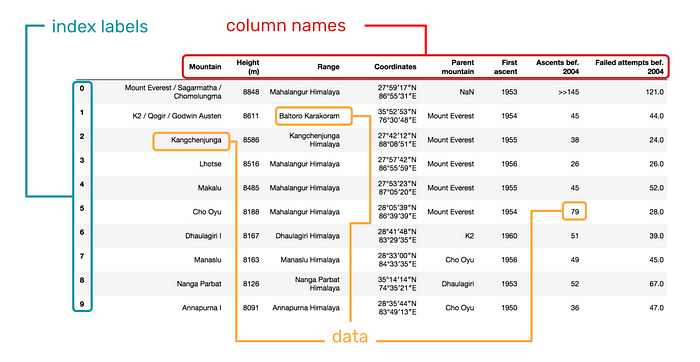

Le concept de ***tidy*** data, popularisé par Hadley Wickham via ses packages `R`,
est parfaitement pertinent pour décrire la structure d’un `DataFrame pandas`.
Les trois règles sont les suivantes :

-   Chaque variable possède sa propre colonne ;
-   Chaque observation possède sa propre ligne ;
-   Une valeur, matérialisant une observation d’une variable,
    se trouve sur une unique cellule.

![Concept de tidy data (emprunté à H. Wickham)](https://d33wubrfki0l68.cloudfront.net/6f1ddb544fc5c69a2478e444ab8112fb0eea23f8/91adc/images/tidy-1.png)

Concernant la syntaxe, une partie des commandes `Python` est inspirée par la logique `SQL`.
On retrouvera ainsi une philosophie proche de celle du SQL où on fait des opérations
de sélection de ligne ou de colonne. Voici une illustration de quelques manipulations de données
que nous mettrons en oeuvre par la suite :

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr class="odd">
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/select_pandas.png" alt="Sélectionner des colonnes" />
<img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/rename_pandas.png" alt="Renommer des colonnes" /></p>
</div></td>
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/mutate_pandas.png" alt="Créer de nouvelles colonnes" />
<img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/filter_pandas.png" alt="Sélectionner des lignes" /></p>
</div></td>
</tr>
</tbody>
</table>

<table style="width:50%;">
<colgroup>
<col style="width: 50%" />
</colgroup>
<tbody>
<tr class="odd">
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/arrange_pandas.png" alt="Réordonner le DataFrame" /></p>
</div></td>
</tr>
</tbody>
</table>

`Pandas` propose énormément de fonctionnalités pré-implémentées.
Il est vivement recommandé, avant de se lancer dans l’écriture d’une
fonction, de se poser la question de son implémentation native dans `Numpy`, `Pandas`, etc.
La plupart du temps, s’il existe une solution implémentée dans une librairie, il convient
de l’utiliser car elle sera plus efficace que celle que vous mettrez en oeuvre.

## Les `Series`

En fait, un *DataFrame* est une collection d’objets appelés `pandas.Series`.
Ces `Series` sont des objets d’une dimension qui sont des extensions des
array-unidimensionnels `numpy`. En particulier, pour faciliter le traitement
de données catégorielles ou temporelles, des types de variables
supplémentaires sont disponibles dans `pandas` par rapport à
`numpy` (`categorical`, `datetime64` et `timedelta64`). Ces
types sont associés à des méthodes optimisées pour faciliter le traitement
de ces données.

Il ne faut pas négliger l’attribut `dtype` d’un objet
`pandas.Series` car cela a une influence déterminante sur les méthodes
et fonctions pouvant être utilisées (on ne fait pas les mêmes opérations
sur une donnée temporelle et une donnée catégorielle) et le volume en
mémoire d’une variable (le type de la variable détermine le volume
d’information stockée pour chaque élément ; être trop précis est parfois
néfaste).

Il existe plusieurs types possibles pour un `pandas.Series`.
Le type `object` correspond aux types Python `str` ou `mixed`.
Il existe un type particulier pour les variables dont le nombre de valeurs
est une liste finie et relativement courte, le type `category`.
Il faut bien examiner les types de son DataFrame, et convertir éventuellement
les types lors de l’étape de `data cleaning`.

### Indexation

La différence essentielle entre une `Series` et un objet `numpy` est l’indexation.
Dans `numpy`,
l’indexation est implicite ; elle permet d’accéder à une donnée (celle à
l’index situé à la position *i*).
Avec une `Series`, on peut bien sûr utiliser un indice de position mais on peut
surtout faire appel à des indices plus explicites.
Par exemple,

In [5]:
taille = pd.Series(
    [1.,1.5,1],
    index = ['chat', 'chien', 'koala']
)

taille.head()

chat     1.0
chien    1.5
koala    1.0
dtype: float64

Cette indexation permet d’accéder à des valeurs de la `Series`
via une valeur de l’indice. Par
exemple, `taille['koala']`:

In [6]:
taille['koala']

1.0

L’existence d’indice rend le *subsetting* particulièrement aisé, ce que vous
pouvez expérimenter dans les TP :

<p class="badges">

<a href="https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" class="github"><i class="fab fa-github"></i></a>
<a href="https://downgit.github.io/#/home?url=https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Download-Notebook-important?logo=Jupyter" alt="Download"></a>
<a href="https://nbviewer.jupyter.org/github/linogaliana/python-datascientist-notebooksblob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Visualize-nbviewer-blue?logo=Jupyter" alt="nbviewer"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/jupyter-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-jupyter.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_Jupyter-orange?logo=Jupyter&logoColor=orange" alt="Onyxia"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/vscode-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-vscode.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_VSCode-blue?logo=visualstudiocode&logoColor=blue" alt="Onyxia"></a><br>
<a href="https://colab.research.google.com/github/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>
<a href="https://github.dev/linogaliana/python-datascientist-notebooks/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/static/v1?logo=visualstudiocode&label=&message=Open%20in%20Visual%20Studio%20Code&labelColor=2c2c32&color=007acc&logoColor=007acc" alt="githubdev"></a>

</p>

</p>

Pour transformer un objet `pandas.Series` en array `numpy`,
on utilise la méthode `values`. Par exemple, `taille.values`:

In [8]:
taille.values

array([1. , 1.5, 1. ])

Un avantage des `Series` par rapport à un *array* `numpy` est que
les opérations sur les `Series` alignent
automatiquement les données à partir des labels.
Avec des `Series` labélisées, il n’est ainsi pas nécessaire
de se poser la question de l’ordre des lignes.
L’exemple dans la partie suivante permettra de s’en assurer.

### Valeurs manquantes

Par défaut, les valeurs manquantes sont affichées `NaN` et sont de type `np.nan` (pour
les valeurs temporelles, i.e. de type `datatime64`, les valeurs manquantes sont
`NaT`).

On a un comportement cohérent d’agrégation lorsqu’on combine deux `DataFrames` (ou deux colonnes).
Par exemple,

In [9]:
x = pd.DataFrame(
    {'prix': np.random.uniform(size = 5),
     'quantite': [i+1 for i in range(5)]
    },
    index = ['yaourt','pates','riz','tomates','gateaux']
)
x

In [10]:
y = pd.DataFrame(
    {'prix': [np.nan, 0, 1, 2, 3],
     'quantite': [i+1 for i in range(5)]
    },
    index = ['tomates','yaourt','gateaux','pates','riz']
)
y

In [11]:
x + y

donne bien une valeur manquante pour la ligne `tomates`. Au passage, on peut remarquer que l’agrégation
a tenu compte des index.

Il est possible de supprimer les valeurs manquantes grâce à `dropna()`.
Cette méthode va supprimer toutes les lignes où il y a au moins une valeur manquante.
Il est aussi possible de supprimer seulement les colonnes où il y a des valeurs manquantes
dans un DataFrame avec `dropna()` avec le paramètre `axis=1` (par défaut égal à 0).

Il est également possible de remplir les valeurs manquantes grâce à la méthode `fillna()`.

## Le DataFrame `Pandas`

Le `DataFrame` est l’objet central de la librairie `pandas`.
Il s’agit d’une collection de `pandas.Series` (colonnes) alignées par les index.
Les types des variables peuvent différer.

Un `DataFrame` non-indexé a la structure suivante :

In [12]:
df = pd.DataFrame(
    {'taille': [1.,1.5,1],
    'poids' : [3, 5, 2.5]
    },
    index = ['chat', 'chien', 'koala']
)
df.reset_index()

Alors que le même `DataFrame` indexé aura la structure suivante :

In [13]:
df = pd.DataFrame(
    {'taille': [1.,1.5,1],
    'poids' : [3, 5, 2.5]
    },
    index = ['chat', 'chien', 'koala']
)
df.head()

### Les attributs et méthodes utiles

Pour présenter les méthodes les plus pratiques pour l’analyse de données,
on peut partir de l’exemple des consommations de CO2 communales issues
des données de l’Ademe. Cette base de données est exploitée plus intensément
dans le TP.

<p class="badges">

<a href="https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" class="github"><i class="fab fa-github"></i></a>
<a href="https://downgit.github.io/#/home?url=https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Download-Notebook-important?logo=Jupyter" alt="Download"></a>
<a href="https://nbviewer.jupyter.org/github/linogaliana/python-datascientist-notebooksblob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Visualize-nbviewer-blue?logo=Jupyter" alt="nbviewer"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/jupyter-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-jupyter.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_Jupyter-orange?logo=Jupyter&logoColor=orange" alt="Onyxia"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/vscode-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-vscode.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_VSCode-blue?logo=visualstudiocode&logoColor=blue" alt="Onyxia"></a><br>
<a href="https://colab.research.google.com/github/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>
<a href="https://github.dev/linogaliana/python-datascientist-notebooks/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/static/v1?logo=visualstudiocode&label=&message=Open%20in%20Visual%20Studio%20Code&labelColor=2c2c32&color=007acc&logoColor=007acc" alt="githubdev"></a>

</p>

</p>

L’import de données depuis un fichier plat se fait avec la fonction [`read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html):

In [15]:
df = pd.read_csv("https://koumoul.com/s/data-fair/api/v1/datasets/igt-pouvoir-de-rechauffement-global/convert")
df

35798 rows × 12 columns

<div class="alert alert-info" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #007bff80;">
<h3 class="alert-heading"><i class="fa fa-comment"></i> Note</h3>

Dans un processus de production, où normalement on connait les types des variables du `DataFrame` qu’on va importer,
il convient de préciser les types avec lesquels on souhaite importer les données
(argument `dtype`, sous la forme d’un dictionnaire).
Cela est particulièrement important lorsqu’on désire utiliser une colonne
comme une variable textuelle mais qu’elle comporte des attributs proches d’un nombre
qui vont inciter `pandas` à l’importer sous forme de variable numérique.

Par exemple, une colonne `[00001,00002,...]` risque d’être importée comme une variable numérique, ignorant l’information des premiers 0 (qui peuvent pourtant la distinguer de la séquence 1, 2, etc.). Pour s’assurer que `pandas` importe sous forme textuelle la variable, on peut utiliser `dtype = {"code": "str"}`
Sinon, on peut importer le csv, et modifier les types avec `astype()`.
Avec `astype`, on peut gérer les erreurs de conversion avec le paramètre `errors`.

</div>

L’affichage des DataFrames est très ergonomique. On obtiendrait le même *output*
avec `display(df)`. Les premières et dernières lignes s’affichent
automatiquement. Autrement, on peut aussi faire:

-   `head` qui permet, comme son
    nom l’indique, de n’afficher que les premières lignes ;
-   `tail` qui permet, comme son
    nom l’indique, de n’afficher que les dernières lignes
-   `sample` qui permet d’afficher un échantillon aléatoire de *n* lignes.
    Cette méthode propose de nombreuses options.

<div class="alert alert-danger" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left: .2rem solid #ff0039;">
<i class="fa fa-exclamation-triangle"></i> Warning</h3>

Il faut faire attention au `display` et aux
commandes qui révèlent des données (`head`, `tail`, etc.)
dans un `Notebook` ou un `Markdown` qui exploite
des données confidentielles lorsqu’on utilise `Git`.

En effet, on peut se
retrouver à partager des données, involontairement, dans l’historique
`Git`. Avec un `R Markdown`, il suffit d’ajouter les sorties au fichier
`.gitignore` (par exemple avec une balise de type `*.html`). Avec un
`Notebook Jupyter`, la démarche est plus compliquée car les fichiers
`.ipynb` intègrent dans le même document, texte, sorties et mise en forme.

Techniquement, il est possible d’appliquer des filtres avec `Git`
(voir
[ici](http://timstaley.co.uk/posts/making-git-and-jupyter-notebooks-play-nice/))
mais c’est une démarche très complexe.
Ce post de l’équipe à l’origine de [nbdev2](https://www.fast.ai/posts/2022-08-25-jupyter-git.html)
résume bien le problème du contrôle de version avec `Git` et des solutions qui
peuvent y être apportées.

Une solution est d’utiliser [`Quarto`](https://quarto.org/) qui permet de générer les
`.ipynb` en *output* d’un document texte, ce qui facilite le contrôle sur les
éléments présents dans le document.

</div>

### Dimensions et structure du DataFrame

Les premières méthodes utiles permettent d’afficher quelques
attributs d’un `DataFrame`.

In [16]:
df.axes

[RangeIndex(start=0, stop=35798, step=1),
 Index(['INSEE commune', 'Commune', 'Agriculture', 'Autres transports',
        'Autres transports international', 'CO2 biomasse hors-total', 'Déchets',
        'Energie', 'Industrie hors-énergie', 'Résidentiel', 'Routier',
        'Tertiaire'],
       dtype='object')]

In [17]:
df.columns

Index(['INSEE commune', 'Commune', 'Agriculture', 'Autres transports',
       'Autres transports international', 'CO2 biomasse hors-total', 'Déchets',
       'Energie', 'Industrie hors-énergie', 'Résidentiel', 'Routier',
       'Tertiaire'],
      dtype='object')

In [18]:
df.index

RangeIndex(start=0, stop=35798, step=1)

Pour connaître les dimensions d’un DataFrame, on peut utiliser quelques méthodes
pratiques :

In [19]:
df.ndim

2

In [20]:
df.shape

(35798, 12)

In [21]:
df.size

429576

Pour déterminer le nombre de valeurs uniques d’une variable, plutôt que chercher à écrire soi-même une fonction,
on utilise la
méthode `nunique`. Par exemple,

In [22]:
df['Commune'].nunique()

33338

`pandas` propose énormément de méthodes utiles.
Voici un premier résumé, accompagné d’un comparatif avec `R` :

| Opération                                             | pandas                  | dplyr (`R`)                          | data.table (`R`)            |
|-------------------------|------------|--------------|-----------------------|
| Récupérer le nom des colonnes                         | `df.columns`            | `colnames(df)`                       | `colnames(df)`              |
| Récupérer les indices                                 | `df.index`              |                                      | `unique(df[,get(key(df))])` |
| Récupérer les dimensions                              | `df.shape`              | `dim(df)`                            | `dim(df)`                   |
| Récupérer le nombre de valeurs uniques d’une variable | `df['myvar'].nunique()` | `df %>%  summarise(distinct(myvar))` | `df[,uniqueN(myvar)]`       |

### Statistiques agrégées

`pandas` propose une série de méthodes pour faire des statistiques
agrégées de manière efficace.

On peut, par exemple, appliquer des méthodes pour compter le nombre de lignes,
faire une moyenne ou une somme de l’ensemble des lignes

In [23]:
df.count()

INSEE commune                      35798
Commune                            35798
Agriculture                        35736
Autres transports                   9979
Autres transports international     2891
CO2 biomasse hors-total            35798
Déchets                            35792
Energie                            34490
Industrie hors-énergie             34490
Résidentiel                        35792
Routier                            35778
Tertiaire                          35798
dtype: int64

In [24]:
df.mean(numeric_only = True)

Agriculture                        2459.975760
Autres transports                   654.919940
Autres transports international    7692.344960
CO2 biomasse hors-total            1774.381550
Déchets                             410.806329
Energie                             662.569846
Industrie hors-énergie             2423.127789
Résidentiel                        1783.677872
Routier                            3535.501245
Tertiaire                          1105.165915
dtype: float64

In [25]:
df.sum(numeric_only = True)

Agriculture                        8.790969e+07
Autres transports                  6.535446e+06
Autres transports international    2.223857e+07
CO2 biomasse hors-total            6.351931e+07
Déchets                            1.470358e+07
Energie                            2.285203e+07
Industrie hors-énergie             8.357368e+07
Résidentiel                        6.384140e+07
Routier                            1.264932e+08
Tertiaire                          3.956273e+07
dtype: float64

In [26]:
df.nunique()

INSEE commune                      35798
Commune                            33338
Agriculture                        35576
Autres transports                   9963
Autres transports international     2883
CO2 biomasse hors-total            35798
Déchets                            11016
Energie                             1453
Industrie hors-énergie              1889
Résidentiel                        35791
Routier                            35749
Tertiaire                           8663
dtype: int64

In [27]:
df.quantile(q = [0.1,0.25,0.5,0.75,0.9], numeric_only = True)

<div class="alert alert-danger" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left: .2rem solid #ff0039;">
<i class="fa fa-exclamation-triangle"></i> Warning</h3>

La version 2.0 de `Pandas` a introduit un changement
de comportement dans les méthodes d’agrégation.

Il est dorénavant nécessaire de préciser quand on désire
effectuer des opérations si on désire ou non le faire
exclusivement sur les colonnes numériques. C’est pour cette
raison qu’on exlicite ici l’argument `numeric_only = True`.
Ce comportement
était par le passé implicite.

</div>

Il faut toujours regarder les options de ces fonctions en termes de valeurs manquantes, car
ces options sont déterminantes dans le résultat obtenu.

Les exercices de TD visent à démontrer l’intérêt de ces méthodes dans quelques cas précis.

<p class="badges">

<a href="https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" class="github"><i class="fab fa-github"></i></a>
<a href="https://downgit.github.io/#/home?url=https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Download-Notebook-important?logo=Jupyter" alt="Download"></a>
<a href="https://nbviewer.jupyter.org/github/linogaliana/python-datascientist-notebooksblob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Visualize-nbviewer-blue?logo=Jupyter" alt="nbviewer"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/jupyter-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-jupyter.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_Jupyter-orange?logo=Jupyter&logoColor=orange" alt="Onyxia"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/vscode-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-vscode.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_VSCode-blue?logo=visualstudiocode&logoColor=blue" alt="Onyxia"></a><br>
<a href="https://colab.research.google.com/github/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>
<a href="https://github.dev/linogaliana/python-datascientist-notebooks/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/static/v1?logo=visualstudiocode&label=&message=Open%20in%20Visual%20Studio%20Code&labelColor=2c2c32&color=007acc&logoColor=007acc" alt="githubdev"></a>

</p>

</p>

Le tableau suivant récapitule le code équivalent pour avoir des
statistiques sur toutes les colonnes d’un dataframe en `R`.

| Opération                        | pandas       | dplyr (`R`)                                            | data.table (`R`)                                      |
|-------------------------|------------|--------------|-----------------------|
| Nombre de valeurs non manquantes | `df.count()` | `df %>% summarise_each(funs(sum(!is.na(.))))`          | `df[, lapply(.SD, function(x) sum(!is.na(x)))]`       |
| Moyenne de toutes les variables  | `df.mean()`  | `df %>% summarise_each(funs(mean((., na.rm = TRUE))))` | `df[,lapply(.SD, function(x) mean(x, na.rm = TRUE))]` |

La méthode `describe` permet de sortir un tableau de statistiques
agrégées :

In [29]:
df.describe()

### Méthodes relatives aux valeurs manquantes

Les méthodes relatives aux valeurs manquantes peuvent être mobilisées
en conjonction des méthodes de statistiques agrégées. C’est utile lorsqu’on
désire obtenir une idée de la part de valeurs manquantes dans un jeu de
données

In [30]:
df.isnull().sum()

INSEE commune                          0
Commune                                0
Agriculture                           62
Autres transports                  25819
Autres transports international    32907
CO2 biomasse hors-total                0
Déchets                                6
Energie                             1308
Industrie hors-énergie              1308
Résidentiel                            6
Routier                               20
Tertiaire                              0
dtype: int64

On trouvera aussi la référence à `isna()` qui est la même méthode que `isnull()`.

## Graphiques rapides

Les méthodes par défaut de graphiques
(approfondies dans la [partie visualisation](#visualisation))
sont pratiques pour
produire rapidement un graphique, notamment après des opérations
complexes de maniement de données.

En effet, on peut appliquer la méthode `plot()` directement à une `pandas.Series` :

In [31]:
df['Déchets'].plot()
df['Déchets'].hist()
df['Déchets'].plot(kind = 'hist', logy = True)

<Axes: ylabel='Frequency'>

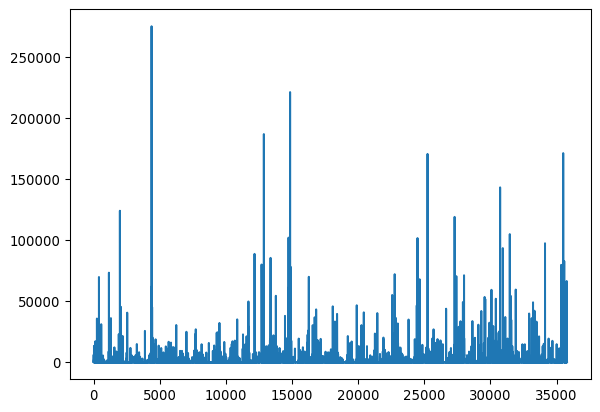

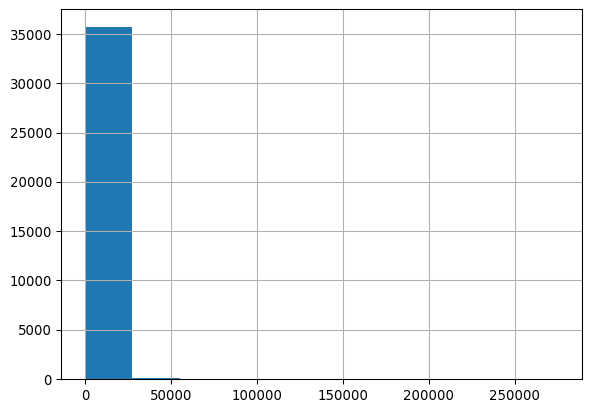

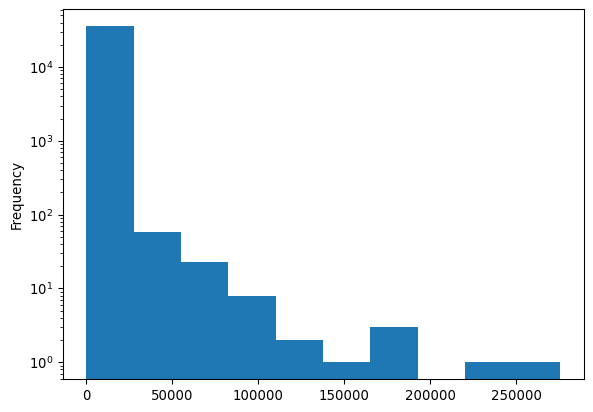

In [32]:
plt.figure()
fig = df['Déchets'].plot()
fig
#plt.savefig('plot_base.png', bbox_inches='tight')

plt.figure()
fig = df['Déchets'].hist()
fig
#plt.savefig('plot_hist.png', bbox_inches='tight')

plt.figure()
fig = df['Déchets'].plot(kind = 'hist', logy = True)
fig
#plt.show()
#plt.savefig('plot_hist_log.png', bbox_inches='tight')

La sortie est un objet `matplotlib`. La *customisation* de ces
figures est ainsi
possible (et même désirable car les graphiques `matplotlib`
sont, par défaut, assez rudimentaires), nous en verrons quelques exemples.

## Accéder à des éléments d’un DataFrame

### Sélectionner des colonnes

En SQL, effectuer des opérations sur les colonnes se fait avec la commande
`SELECT`. Avec `pandas`,
pour accéder à une colonne dans son ensemble on peut
utiliser plusieurs approches :

-   `dataframe.variable`, par exemple `df.Energie`.
    Cette méthode requiert néanmoins d’avoir des
    noms de colonnes sans espace.
-   `dataframe[['variable']]` pour renvoyer la variable sous
    forme de `DataFrame` ou `dataframe['variable']` pour
    la renvoyer sous forme de `Series`. Par exemple, `df[['Autres transports']]`
    ou `df['Autres transports']`. C’est une manière préférable de procéder.

### Accéder à des lignes

Pour accéder à une ou plusieurs valeurs d’un `DataFrame`,
il existe deux manières conseillées de procéder, selon la
forme des indices de lignes ou colonnes utilisées :

-   `df.loc` : utilise les labels
-   `df.iloc` : utilise les indices

<div class="alert alert-danger" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left: .2rem solid #ff0039;">
<i class="fa fa-exclamation-triangle"></i> Warning</h3>

Les bouts de code utilisant la structure `df.ix`
sont à bannir car la fonction est *deprecated* et peut
ainsi disparaître à tout moment.

</div>

`iloc` va se référer à l’indexation de 0 à *N* où *N* est égal à `df.shape[0]` d’un
`pandas.DataFrame`. `loc` va se référer aux valeurs de l’index
de `df`.

Par exemple, avec le `pandas.DataFrame` `df_example`:

In [33]:
df_example = pd.DataFrame(
    {'month': [1, 4, 7, 10], 'year': [2012, 2014, 2013, 2014], 'sale': [55, 40, 84, 31]})
df_example = df_example.set_index('month')
df_example

-   `df_example.loc[1, :]` donnera la première ligne de `df` (ligne où l’indice `month` est égal à 1) ;
-   `df_example.iloc[1, :]` donnera la deuxième ligne (puisque l’indexation en `Python` commence à 0) ;
-   `df_example.iloc[:, 1]` donnera la deuxième colonne, suivant le même principe.

## Principales manipulation de données

L’objectif du [TP pandas](#pandasTP) est de se familiariser plus avec ces
commandes à travers l’exemple des données des émissions de C02.

Les opérations les plus fréquentes en `SQL` sont résumées par le tableau suivant.
Il est utile de les connaître (beaucoup de syntaxes de maniement de données
reprennent ces termes) car, d’une
manière ou d’une autre, elles couvrent la plupart
des usages de manipulation des données

| Opération                                                        | SQL                                                              | pandas                                                 | dplyr (`R`)                                        | data.table (`R`)                                 |
|--------|---------------|-----------|-----------------|-----------------------|
| Sélectionner des variables par leur nom                          | `SELECT`                                                         | `df[['Autres transports','Energie']]`                  | `df %>% select(Autres transports, Energie)`        | `df[, c('Autres transports','Energie')]`         |
| Sélectionner des observations selon une ou plusieurs conditions; | `FILTER`                                                         | `df[df['Agriculture']>2000]`                           | `df %>% filter(Agriculture>2000)`                  | `df[Agriculture>2000]`                           |
| Trier la table selon une ou plusieurs variables                  | `SORT BY`                                                        | `df.sort_values(['Commune','Agriculture'])`            | `df %>% arrange(Commune, Agriculture)`             | `df[order(Commune, Agriculture)]`                |
| Ajouter des variables qui sont fonction d’autres variables;      | `SELECT *, LOG(Agriculture) AS x FROM df`                        | `df['x'] = np.log(df['Agriculture'])`                  | `df %>% mutate(x = log(Agriculture))`              | `df[,x := log(Agriculture)]`                     |
| Effectuer une opération par groupe                               | `GROUP BY`                                                       | `df.groupby('Commune').mean()`                         | `df %>% group_by(Commune) %>% summarise(m = mean)` | `df[,mean(Commune), by = Commune]`               |
| Joindre deux bases de données (*inner join*)                     | `SELECT * FROM table1 INNER JOIN table2 ON table1.id = table2.x` | `table1.merge(table2, left_on = 'id', right_on = 'x')` | `table1 %>% inner_join(table2, by = c('id'='x'))`  | `merge(table1, table2, by.x = 'id', by.y = 'x')` |

### Opérations sur les colonnes : `select`, `mutate`, `drop`

Les `DataFrames` pandas sont des objets *mutables* en langage `Python`,
c’est-à-dire qu’il est possible de faire évoluer le `DataFrame` au grès
des opérations. L’opération la plus classique consiste à ajouter ou retirer
des variables à la table de données.

In [34]:
df_new = df.copy()

<div class="alert alert-danger" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left: .2rem solid #ff0039;">
<i class="fa fa-exclamation-triangle"></i> Warning</h3>

Attention au comportement de `pandas` lorsqu’on crée une duplication
d’un `DataFrame`.

Par défaut, `pandas` effectue une copie par référence. Dans ce
cas, les deux objets (la copie et l’objet copié) restent reliés. Les colonnes
créées sur l’un vont être répercutées sur l’autre. Ce comportement permet de
limiter l’inflation en mémoire de `Python`. En faisant ça, le deuxième
objet prend le même espace mémoire que le premier. Le package `data.table`
en `R` adopte le même comportement, contrairement à `dplyr`.

Cela peut amener à quelques surprises si ce comportement d’optimisation
n’est pas anticipé. Si vous voulez, par sécurité, conserver intact le
premier DataFrame, faites appel à une copie profonde (*deep copy*) en
utilisant la méthode `copy`, comme ci-dessus.

Attention toutefois, cela a un coût mémoire.
Avec des données volumineuses, c’est une pratique à utiliser avec précaution.

</div>

La manière la plus simple d’opérer pour ajouter des colonnes est
d’utiliser la réassignation. Par exemple, pour créer une variable
`x` qui est le `log` de la
variable `Agriculture`:

In [35]:
df_new['x'] = np.log(df_new['Agriculture'])

Il est possible d’appliquer cette approche sur plusieurs colonnes. Un des
intérêts de cette approche est qu’elle permet de recycler le nom de colonnes.

In [36]:
vars = ['Agriculture', 'Déchets', 'Energie']

df_new[[v + "_log" for v in vars]] = np.log(df_new[vars])
df_new

35798 rows × 16 columns

Il est également possible d’utiliser la méthode `assign`. Pour des opérations
vectorisées, comme le sont les opérateurs de `numpy`, cela n’a pas d’intérêt.

Cela permet notamment d’enchainer les opérations sur un même `DataFrame` (notamment grâce au `pipe` que
nous verrons plus loin).
Cette approche utilise généralement
des *lambda functions*. Par exemple le code précédent (celui concernant une
seule variable) prendrait la forme:

In [37]:
df_new.assign(Energie_log = lambda x: np.log(x['Energie']))

35798 rows × 16 columns

Dans les méthodes suivantes, il est possible de modifier le `pandas.DataFrame`
*en place*, c’est à dire en ne le réassignant pas, avec le paramètre `inplace = True`.
Par défaut, `inplace` est égal à `False` et pour modifier le `pandas.DataFrame`,
il convient de le réassigner.

On peut facilement renommer des variables avec la méthode `rename` qui
fonctionne bien avec des dictionnaires (pour renommer des colonnes il faut
préciser le paramètre `axis = 1`):

In [38]:
df_new = df_new.rename({"Energie": "eneg", "Agriculture": "agr"}, axis=1)

Enfin, pour effacer des colonnes, on utilise la méthode `drop` avec l’argument
`columns`:

In [39]:
df_new = df_new.drop(columns = ["eneg", "agr"])

### Réordonner

La méthode `sort_values` permet de réordonner un `DataFrame`. Par exemple,
si on désire classer par ordre décroissant de consommation de CO2 du secteur
résidentiel, on fera

In [40]:
df = df.sort_values("Résidentiel", ascending = False)

Ainsi, en une ligne de code, on identifie les villes où le secteur
résidentiel consomme le plus.

### Filtrer

L’opération de sélection de lignes s’appelle `FILTER` en SQL. Elle s’utilise
en fonction d’une condition logique (clause `WHERE`). On sélectionne les
données sur une condition logique. Il existe plusieurs méthodes en `pandas`.

La plus simple est d’utiliser les *boolean mask*, déjà vus dans le chapitre
[`numpy`](#numpy).

Par exemple, pour sélectionner les communes dans les Hauts-de-Seine, on
peut utiliser le résultat de la méthode `str.startswith` (qui renvoie
`True` ou `False`) directement dans les crochets:

In [41]:
df[df['INSEE commune'].str.startswith("92")].head(2)

Pour remplacer des valeurs spécifiques, on utilise la méthode `where` ou une
réassignation couplée à la méthode précédente.

Par exemple, pour assigner des valeurs manquantes aux départements du 92,
on peut faire cela

In [42]:
df_copy = df.copy()
df_copy = df_copy.where(~df['INSEE commune'].str.startswith("92"))

et vérifier les résultats:

In [43]:
df_copy[df['INSEE commune'].str.startswith("92")].head(2)
df_copy[~df['INSEE commune'].str.startswith("92")].head(2)

ou alors utiliser une réassignation plus classique:

In [44]:
df_copy = df.copy()
df_copy[df_copy['INSEE commune'].str.startswith("92")] = np.nan

Il est conseillé de filtrer avec `loc` en utilisant un masque.
En effet, contrairement à `df[mask]`, `df.loc[mask, :]` permet d’indiquer clairement
à Python que l’on souhaite appliquer le masque aux labels de l’index.
Ce n’est pas le cas avec `df[mask]`.
D’ailleurs, lorsqu’on utilise la syntaxe `df[mask]`, `pandas` renvoie généralement un *warning*

### Opérations par groupe

En `SQL`, il est très simple de découper des données pour
effectuer des opérations sur des blocs cohérents et recollecter des résultats
dans la dimension appropriée.
La logique sous-jacente est celle du *split-apply-combine* qui est repris
par les langages de manipulation de données, auxquels `pandas`
[ne fait pas exception](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html).

L’image suivante, issue de
[ce site](https://unlhcc.github.io/r-novice-gapminder/16-plyr/)
représente bien la manière dont fonctionne l’approche
`split`-`apply`-`combine`

![Split-apply-combine](https://unlhcc.github.io/r-novice-gapminder/fig/12-plyr-fig1.png)

Ce [tutoriel](https://realpython.com/pandas-groupby/) sur le sujet
est particulièrement utile.

Pour donner quelques exemples, on peut créer une variable départementale qui
servira de critère de groupe.

In [45]:
df['dep'] = df['INSEE commune'].str[:2]

En `pandas`, on utilise `groupby` pour découper les données selon un ou
plusieurs axes. Techniquement, cette opération consiste à créer une association
entre des labels (valeurs des variables de groupe) et des
observations.

Par exemple, pour compter le nombre de communes par département en SQL, on
utiliserait la requête suivante :

``` sql
SELECT dep, count(INSEE commune)
FROM df
GROUP BY dep;
```

Ce qui, en `pandas`, donne:

In [46]:
df.groupby('dep')["INSEE commune"].count()

dep
01    410
02    805
03    318
04    199
05    168
     ... 
91    196
92     36
93     40
94     47
95    185
Name: INSEE commune, Length: 96, dtype: int64

La syntaxe est quasiment transparente. On peut bien sûr effectuer des opérations
par groupe sur plusieurs colonnes. Par exemple,

In [47]:
df.groupby('dep').mean(numeric_only = True)

96 rows × 10 columns

A noter que la variable de groupe, ici `dep`, devient, par défaut, l’index
du DataFrame de sortie. Si on avait utilisé plusieurs variables de groupe,
on obtiendrait un objet multi-indexé. Sur la gestion des `multi-index`, on
pourra se référer à l’ouvrage `Modern Pandas` dont la référence est
donnée en fin de cours.

Tant qu’on n’appelle pas une action sur un `DataFrame` par groupe, du type
`head` ou `display`, `pandas` n’effectue aucune opération. On parle de
*lazy evaluation*. Par exemple, le résultat de `df.groupby('dep')` est
une transformation qui n’est pas encore évaluée :

In [48]:
df.groupby('dep')

Il est possible d’appliquer plus d’une opération à la fois grâce à la méthode
`agg`. Par exemple, pour obtenir à la fois le minimum, la médiane et le maximum
de chaque département, on peut faire:

In [49]:
numeric_columns = df.select_dtypes(['number']).columns
df.loc[:, numeric_columns.tolist() + ["dep"] ].groupby('dep').agg(['min',"median","max"], numeric_only = True)

96 rows × 30 columns

La première ligne est présente pour nous faciliter la récupération des noms de colonnes des variables
numériques

### Appliquer des fonctions

`pandas` est, comme on a pu le voir, un package très flexible, qui
propose une grande variété de méthodes optimisées. Cependant, il est fréquent
d’avoir besoin de méthodes non implémentées.

Dans ce cas, on recourt souvent aux `lambda` functions. Par exemple, si
on désire connaître les communes dont le nom fait plus de 40 caractères,
on peut appliquer la fonction `len` de manière itérative:

In [50]:
# Noms de communes superieurs à 40 caracteres
df[df['Commune'].apply(lambda s: len(s)>40)]

Cependant, toutes les `lambda` functions ne se justifient pas.
Par exemple, prenons
le résultat d’agrégation précédent. Imaginons qu’on désire avoir les résultats
en milliers de tonnes. Dans ce cas, le premier réflexe est d’utiliser
la `lambda` function suivante :

In [51]:
numeric_columns = df.select_dtypes(['number']).columns
(df
    .loc[:, numeric_columns.tolist() + ["dep"] ]
    .groupby('dep')
    .agg(['min',"median","max"])
    .apply(lambda s: s/1000)
)

96 rows × 30 columns

En effet, cela effectue le résultat désiré. Cependant, il y a mieux : utiliser
la méthode `div`:

In [52]:
import timeit
df_numeric = df.loc[:, numeric_columns.tolist() + ["dep"] ]
%timeit df_numeric.groupby('dep').agg(['min',"median","max"]).div(1000)
%timeit df_numeric.groupby('dep').agg(['min',"median","max"]).apply(lambda s: s/1000)

La méthode `div` est en moyenne plus rapide et a un temps d’exécution
moins variable. Dans ce cas, on pourrait même utiliser le principe
du *broadcasting* de numpy (cf. [chapitre numpy](numpy)) qui offre
des performances équivalentes:

In [53]:
%timeit df_numeric.groupby('dep').agg(['min',"median","max"])/1000

`apply` est plus rapide qu’une boucle (en interne, `apply` utilise `Cython`
pour itérer) mais reste moins rapide qu’une solution vectorisée quand
elle existe. Ce [site](https://realpython.com/fast-flexible-pandas/#pandas-apply)
propose des solutions, par exemple les méthodes `isin` ou `digitize`, pour
éviter de manuellement créer des boucles lentes.

En particulier, il faut noter que `apply` avec le paramètre `axis=1` est en générale lente.

### Joindre des données

Il est commun de devoir combiner des données issues de sources différentes.
Nous allons ici nous focaliser sur le cas le plus favorable qui est la situation
où une information permet d’apparier de manière exacte deux bases de données (autrement nous
serions dans une situation, beaucoup plus complexe, d’appariement flou<a name="cite_ref-6"></a>[<sup>\[6\]</sup>](#cite_note-6)).

Sur l’appariement flou, se reporter aux chapitres présentant `ElasticSearch`.

La situation typique est l’appariement entre deux sources de données selon un identifiant
individuel. Ici, il s’agit d’un identifiant de code commune.

Il est recommandé de lire [ce guide assez complet sur la question des jointures avec `R`](https://www.book.utilitr.org/03_fiches_thematiques/fiche_joindre_donnees)
qui donne des recommandations également utiles pour un utilisateur de `Python`.

![](https://external-preview.redd.it/yOLzCR0qSzul2WpjQorxINB0xpU3_N9twmFVsgbGJwQ.jpg?auto=webp&s=4feedc91302ba635b3028a21b98d047def5cdc2b)

On utilise de manière indifférente les termes *merge* ou *join*.
Le deuxième terme provient de la syntaxe SQL.
En `Pandas`, dans la plupart des cas, on peut utiliser indifféremment `df.join` et `df.merge`

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/pandas_join.png)

Il est aussi possible de réaliser un merge en utilisant la fonction `pandas.concat()` avec `axis=1`.
Se référer à la documentation de `concat` pour voir les options possibles.

### Restructurer des données (*reshape*)

On présente généralement deux types de données :

-   format **wide** : les données comportent des observations répétées, pour un même individu (ou groupe), dans des colonnes différentes
-   format **long** : les données comportent des observations répétées, pour un même individu, dans des lignes différentes avec une colonne permettant de distinguer les niveaux d’observations

Un exemple de la distinction entre les deux peut être emprunté à l’ouvrage de référence d’Hadley Wickham, *R for Data Science* :

![](https://d33wubrfki0l68.cloudfront.net/3aea19108d39606bbe49981acda07696c0c7fcd8/2de65/images/tidy-9.png)

L’aide mémoire suivante aidera à se rappeler les fonctions à appliquer si besoin :

![](https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/reshape.png)

Le fait de passer d’un format *wide* au format *long* (ou vice-versa) peut être extrêmement pratique car
certaines fonctions sont plus adéquates sur une forme de données ou sur l’autre.
En règle générale, avec `Python` comme avec `R`, les formats *long* sont souvent préférables.

Le chapitre suivant, qui fait office de TP, proposera des applications de ces principes :

<p class="badges">

<a href="https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" class="github"><i class="fab fa-github"></i></a>
<a href="https://downgit.github.io/#/home?url=https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Download-Notebook-important?logo=Jupyter" alt="Download"></a>
<a href="https://nbviewer.jupyter.org/github/linogaliana/python-datascientist-notebooksblob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/Visualize-nbviewer-blue?logo=Jupyter" alt="nbviewer"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/jupyter-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-jupyter.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_Jupyter-orange?logo=Jupyter&logoColor=orange" alt="Onyxia"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/vscode-python?autoLaunch=true&onyxia.friendlyName=%C2%AB02b_pandas_TP%C2%BB&init.personalInit=%C2%ABhttps%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmaster%2Fsspcloud%2Finit-vscode.sh%C2%BB&init.personalInitArgs=%C2%ABmanipulation%2002b_pandas_TP%C2%BB&security.allowlist.enabled=false" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Tester_avec_VSCode-blue?logo=visualstudiocode&logoColor=blue" alt="Onyxia"></a><br>
<a href="https://colab.research.google.com/github/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>
<a href="https://github.dev/linogaliana/python-datascientist-notebooks/notebooks/manipulation/02b_pandas_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/static/v1?logo=visualstudiocode&label=&message=Open%20in%20Visual%20Studio%20Code&labelColor=2c2c32&color=007acc&logoColor=007acc" alt="githubdev"></a>

</p>

</p>

### Les pipe

En général, dans un projet, le nettoyage de données va consister en un ensemble de
méthodes appliquées à un `pandas.DataFrame`.
On a vu que `assign` permettait de créer une variable dans un `DataFrame`.
Il est également possible d’appliquer une fonction, appelée par exemple `my_udf` au
DataFrame grâce à `pipe`:

``` python
df = (pd.read_csv(path2data)
            .pipe(my_udf))
```

L’utilisation des `pipe` rend le code très lisible et peut être très
pratique lorsqu’on enchaine des opérations sur le même
*dataset*.

## Quelques enjeux de performance

La librairie `Dask` intègre la structure de `numpy`, `pandas` et `sklearn`.
Elle a vocation à traiter de données en grande dimension, ainsi elle ne sera pas
optimale pour des données qui tiennent très bien en RAM.
Il s’agit d’une librairie construite sur la parallélisation.
[Un chapitre dans ce cours](/dask.html) lui est consacré.
Pour aller plus loin, se référer à la [documentation de `Dask`](https://docs.dask.org/en/latest/).

## Références

-   Le site
    [pandas.pydata](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html)
    fait office de référence

-   Le livre `Modern Pandas` de Tom Augspurger : https://tomaugspurger.github.io/modern-1-intro.html

McKinney, Wes. 2012. *Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython*. " O’Reilly Media, Inc.".